In [1]:
import sys
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [2]:
cwd = Path.cwd()
project_root = cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done!")

Done!


In [3]:
transformation = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5,), std=(0.5,))])

In [4]:
lr = 2e-4
batch_size = 128
noise_size = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
train_dataset = datasets.MNIST(
    root=project_root / "data",
    train=True,
    transform=transformation,
)

test_dataset = datasets.MNIST(
    root=project_root / "data",
    train=False,
    transform=transformation,
)

In [6]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size,
                             shuffle=True)

In [7]:
a = torch.randint(low = 1, high=20, size=[2,3,4])
a

tensor([[[19, 18, 17,  4],
         [ 8,  4,  1,  9],
         [ 5,  5,  4,  7]],

        [[ 5, 18,  9,  5],
         [ 8,  2,  2, 19],
         [ 2,  7,  4, 11]]])

In [8]:
a = a.view(2*3, -1)
a

tensor([[19, 18, 17,  4],
        [ 8,  4,  1,  9],
        [ 5,  5,  4,  7],
        [ 5, 18,  9,  5],
        [ 8,  2,  2, 19],
        [ 2,  7,  4, 11]])

In [9]:
# Generator
class Generator(nn.Module):
    def __init__(self, noise_size: int):
        super().__init__()
        self.layer1 = nn.Linear(in_features=noise_size, out_features=512*7*7)
        self.layer2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=4, stride=2, padding=1)
        self.layer3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1)
        self.layer4 = nn.Conv2d(in_channels=128, out_channels=1, kernel_size=3, stride=1, padding=1)
        self.batch_norm_1 = nn.BatchNorm2d(256)
        self.batch_norm_2 = nn.BatchNorm2d(128)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()
        
    def forward(self, X):
        X = self.layer1(X) # (512 * 7 * 7)
        X = X.view(-1, 512, 7, 7) # (128, 512, 7, 7)
        X = self.layer2(X) # (128, 256, 14, 14)
        X = self.batch_norm_1(X)
        X = self.relu(X)
        X = self.layer3(X) # (128, 128, 28, 28)
        X = self.batch_norm_2(X)
        X = self.relu(X)
        X = self.layer4(X) # (128, 1, 28, 28)
        X = self.tanh(X)
        
        return X

In [10]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Conv2d(in_channels=1, out_channels=128, kernel_size=4, stride=2, padding=1)
        self.layer2 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1)
        self.layer3 = nn.Linear(in_features=256*7*7, out_features=1024)
        self.layer4 = nn.Linear(in_features=1024, out_features=1)
        self.batch_norm = nn.BatchNorm2d(256)
        self.l_relu = nn.LeakyReLU()
        self.sigmoid = nn.Sigmoid()
        self.flatten = nn.Flatten()
        
    def forward(self, X):
        X = self.layer1(X)
        X = self.l_relu(X)
        X = self.layer2(X)
        X = self.batch_norm(X)
        X = self.l_relu(X)
        X = self.flatten(X)
        X = self.layer3(X)
        X = self.l_relu(X)
        X = self.layer4(X)
        X = self.sigmoid(X)
        
        return X

In [11]:
generator = Generator(noise_size=noise_size).to(device)
discriminator = Discriminator().to(device)
criterian = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=lr)
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

In [12]:
def train(
    dataloader: DataLoader,
    generator: Generator,
    discriminator: Discriminator,
    criterion,
    noise_size:int,
    device,
    g_optimizer,
    d_optimizer,
    epochs : int = 10,
    k: int = 1
):
    generator.train()
    discriminator.train()
    for epoch in range(epochs):
        d_total_loss = 0
        g_total_loss = 0
        for batch, _ in dataloader:
            for i in range(k):
                batch = batch.to(device)
                noise_sample = torch.randn(size=[batch.shape[0], noise_size]).to(device)
                generated_samples = generator.forward(noise_sample).detach()
                g_labels = torch.zeros(size=[batch.shape[0]]).squeeze().to(device)
                r_labels = torch.ones(size=[batch.shape[0]]).squeeze().to(device)
                g_generator_output = discriminator.forward(generated_samples).squeeze()
                r_generator_output = discriminator.forward(batch).squeeze()
                g_cost = criterion(g_generator_output, g_labels)
                r_cost = criterion(r_generator_output, r_labels)
                d_optimizer.zero_grad()
                d_loss = g_cost + r_cost
                d_total_loss += d_loss.item()
                d_loss.backward()
                d_optimizer.step()
            new_noise_sample = torch.randn(size=[batch.shape[0], noise_size]).to(device)
            new_fake_samples = generator.forward(new_noise_sample)
            new_d_output = discriminator.forward(new_fake_samples).squeeze()
            new_labels = torch.ones(size=[batch.shape[0]]).to(device)
            g_optimizer.zero_grad()
            new_g_cost = criterion(new_d_output, new_labels)
            g_total_loss += new_g_cost.item()
            new_g_cost.backward()
            g_optimizer.step()
            
        print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_total_loss:.4f} | G Loss: {g_total_loss:.4f}")
    return generator, discriminator

In [13]:
def visualize(generator: Generator, noise_size, device, n=16):
    generator.eval()
    with torch.no_grad():
        noise_data = torch.randn(size=[n, noise_size]).to(device)
        output = generator.forward(noise_data)
        output = output.cpu()
        output = output.squeeze(1)
        output = (output + 1)/2
        
        figs, axes = plt.subplots(nrows=4, ncols=4, figsize=(8,8))
        for i in range(n):
            row = i // 4
            col = i % 4
            axes[row][col].imshow(output[i], cmap='gray')
            axes[row][col].axis('off')
    
    plt.show()

In [ ]:
trained_generator, trained_discriminator = train(
    dataloader=train_dataloader,
    generator=generator,
    discriminator=discriminator,
    criterion=criterian,
    noise_size=noise_size,
    device=device,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    epochs=50,
)

In [14]:
checkpth_path = project_root / "data" / "dcgan_checkpoint.pth"

In [17]:
loaded_checkpoint = torch.load(str(checkpth_path), map_location=device, weights_only=False)

In [21]:
loaded_noise_size = loaded_checkpoint["noise_size"]

loaded_discriminator = loaded_checkpoint["DUGAN_discriminator_state_dict"]
loaded_generator = loaded_checkpoint["DUGAN_generator_state_dict"]

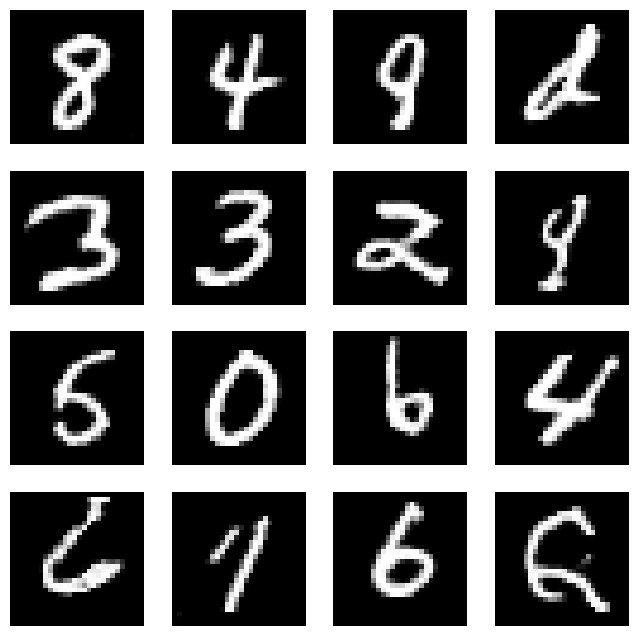

In [27]:
visualize(
    generator=loaded_generator,
    noise_size=loaded_noise_size,
    device=device
)